
Dataset Loaded Successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

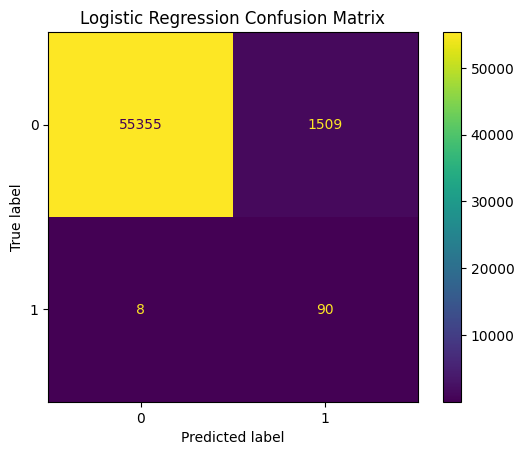

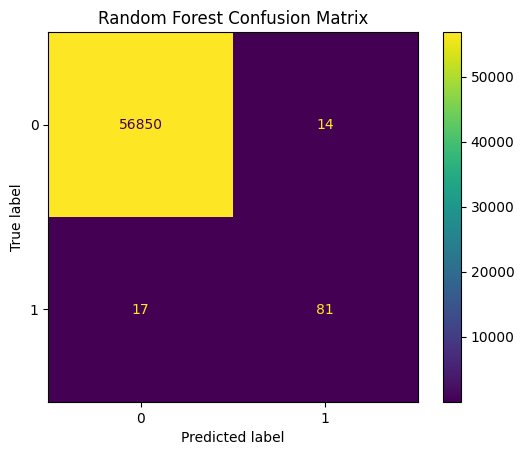

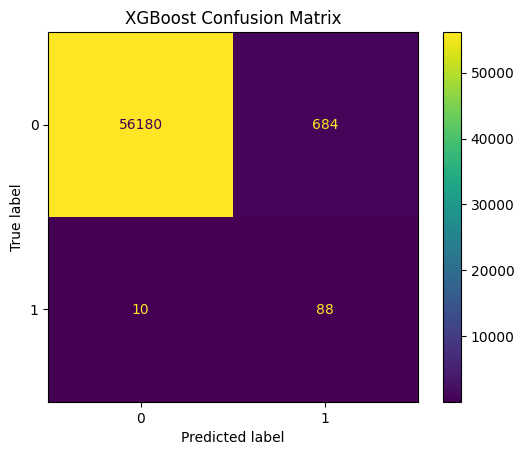


✅ PIPELINE COMPLETED SUCCESSFULLY


In [7]:
# ============================================
# FRAUD DETECTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ============================================
# LOAD DATA
# ============================================

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
data = pd.read_csv(url)

print("\nDataset Loaded Successfully")
print(data.head())

# ============================================
# SAFE COLUMN HANDLING
# ============================================

# ONLY DROP 'Time' IF IT EXISTS
if "Time" in data.columns:
    data = data.drop("Time", axis=1)

# ============================================
# PREPROCESSING
# ============================================

scaler = StandardScaler()

data["Amount"] = scaler.fit_transform(data[["Amount"]])

X = data.drop("Class", axis=1)
y = data["Class"]

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ============================================
# SMOTE
# ============================================

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train_sm.value_counts(normalize=True))

# ============================================
# MODELS
# ============================================

lr = LogisticRegression(max_iter=500)

rf = RandomForestClassifier(n_estimators=50, random_state=42)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

lr.fit(X_train_sm, y_train_sm)
rf.fit(X_train_sm, y_train_sm)
xgb.fit(X_train_sm, y_train_sm)

# ============================================
# EVALUATION
# ============================================

def evaluate(name, model):
    pred = model.predict(X_test)
    print("\n======================")
    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    return pred

lr_pred = evaluate("Logistic Regression", lr)
rf_pred = evaluate("Random Forest", rf)
xgb_pred = evaluate("XGBoost", xgb)

# ============================================
# CONFUSION MATRICES
# ============================================

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)
plt.title("XGBoost Confusion Matrix")
plt.show()

print("\n✅ PIPELINE COMPLETED SUCCESSFULLY")